In [18]:
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060
Using device    : cuda


In [40]:
"""
SkinLesionClassifier_V6 - Morphology-Aware Cross-Attention Fusion
=================================================================
Phase 3: Pivot from metadata to morphology-based multimodal fusion.

Key Changes from V5:
1. REMOVED: Metadata branch (age/sex/site) - proven weak signal
2. ADDED: Morphology extractor (OpenCV contour analysis)
3. ADDED: 5 ABCD features per mask (area, asymmetry, border, compactness, diameter)
4. ADDED: Cross-attention fusion (image queries → morphology keys/values)
5. KEPT: Swin-UNet encoder, FPN, mask guidance, training infrastructure

Target: Beat V4-C baseline (83.5% accuracy, 0.7331 macro F1)
"""

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, 
                             classification_report, confusion_matrix)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

try:
    from tqdm.auto import tqdm
except ImportError:
    class _NoOpTqdm:
        def __init__(self, iterable, **kwargs):
            self.iterable = iterable
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, *args, **kwargs):
            pass
    def tqdm(iterable, **kwargs):
        return _NoOpTqdm(iterable, **kwargs)


In [39]:
class Config:
    """Central configuration — update DATA_DIR to your actual path."""
    DATA_DIR       = r'D:\dataset'
    IMAGE_DIR      = os.path.join(DATA_DIR, 'images/')
    MASK_DIR       = os.path.join(DATA_DIR, 'mask/')
    METADATA_CSV   = os.path.join(DATA_DIR, 'metadata\HAM10000_metadata.csv')
    ENCODER_CKPT   = r'D:\PHASE 6\swinunet\swinunet_v4_encoder.pth'
    CHECKPOINT_DIR = r'D:\Kimi phase 3\output\checkpoints_phase3'

    # Backward-compatible aliases used by later notebook cells.
    ENCODER_CHECKPOINT = ENCODER_CKPT
    SAVE_DIR = CHECKPOINT_DIR

    # Training
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0  
    NUM_CLASSES = 7

    # Phase 1 (frozen encoder)
    PHASE1_EPOCHS = 10
    PHASE1_LR = 1e-3

    # Phase 2 (unfrozen encoder)
    PHASE2_EPOCHS = 50
    ENCODER_LR = 1e-5
    HEAD_LR = 5e-5

    # Early stopping
    EARLY_STOPPING_PATIENCE = 10

    # Cross-attention
    FUSION_DIM = 512
    NUM_HEADS = 8
    DROPOUT = 0.1

    # Morphology
    MORPH_DIM = 32

    # Device
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [41]:
def set_seed(seed=42):
    """Set random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [42]:
def extract_morphology(mask_np):
    """
    Extract 5 clinically meaningful morphology features from segmentation mask.

    Features (ABCD criteria inspired):
    1. Asymmetry (A): 1 - (minor_axis / major_axis)
    2. Border irregularity (B): 1 - compactness (deviation from circle)
    3. Color variance (C): placeholder - computed from masked image if available
    4. Compactness: (4*pi*area) / perimeter^2
    5. Diameter (D): sqrt(4*area/pi) / image_size

    Args:
        mask_np: numpy array (H, W) with values in [0, 1]
    Returns:
        features: numpy array (5,) with morphology features
    """
    # Binarize mask
    mask_bin = (mask_np > 0.5).astype(np.uint8)

    # Find contours — compatible with OpenCV 3.x and 4.x
    result = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = result[0] if len(result) == 2 else result[1]

    if not contours:
        # No lesion found - return zeros
        return np.zeros(5, dtype=np.float32)

    # Largest contour (the lesion)
    cnt = max(contours, key=cv2.contourArea)

    # Basic measurements
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if area < 10 or perimeter < 1:
        return np.zeros(5, dtype=np.float32)

    # A: Asymmetry (1 - ratio of axes)
    asymmetry = 0.0
    if len(cnt) >= 5:
        try:
            _, axes, _ = cv2.fitEllipse(cnt)
            major = max(axes)
            minor = min(axes)
            if major > 0:
                asymmetry = 1.0 - (minor / major)
        except Exception:
            asymmetry = 0.0

    # B: Border irregularity (deviation from perfect circle)
    compactness = (4.0 * np.pi * area) / (perimeter ** 2 + 1e-8)
    border_irregularity = 1.0 - compactness  # Higher = more irregular

    # C: Color variance (placeholder - will be populated from masked image)
    # This is computed separately if RGB image is available
    color_variance = 0.0

    # D: Diameter (normalized by image size)
    diameter = np.sqrt(4.0 * area / np.pi) / 224.0  # Normalize by 224x224

    features = np.array([
        asymmetry,           # [0, 1], higher = more asymmetric
        border_irregularity, # [0, 1], higher = more irregular
        color_variance,      # [0, inf), populated later if image available
        compactness,         # [0, 1], higher = more circular
        diameter             # [0, 1], relative to image size
    ], dtype=np.float32)

    return features

In [43]:
def extract_morphology_with_color(mask_np, image_np):
    """
    Extract morphology features INCLUDING color variance from masked image.

    Args:
        mask_np: numpy array (H, W) mask
        image_np: numpy array (H, W, 3) RGB image
    Returns:
        features: numpy array (5,) with morphology features
    """
    features = extract_morphology(mask_np)

    # Compute color variance from masked image
    mask_bin = (mask_np > 0.5).astype(np.uint8)
    if mask_bin.sum() > 0:
        # Extract pixels inside mask
        masked_pixels = image_np[mask_bin > 0]  # (N, 3)
        if len(masked_pixels) > 0:
            # Color variance (standard deviation across channels)
            color_std = np.std(masked_pixels, axis=0).mean()
            # Normalize (typical std is 0-50 for uint8 images)
            features[2] = color_std / 50.0  # Normalized to [0, 1] approx

    return features

In [44]:
class HAM10000Dataset_Morphology(Dataset):
    """
    HAM10000 Dataset with image, mask, and morphology features.

    Returns:
        dict with keys: 'image', 'mask', 'morphology', 'label'
    """

    def __init__(self, df, img_dir, mask_dir, transform=None, mode='train', img_size=224):
        """
        Args:
            df: DataFrame with image_id, label
            img_dir: Directory containing images
            mask_dir: Directory containing masks
            transform: Albumentations transforms
            mode: 'train', 'val', or 'test'
            img_size: target size for morphology extraction
        """
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mode = mode
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        label = row['label']

        # Load image
        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = np.array(Image.open(img_path).convert("RGB"))

        # Load mask
        mask_path = os.path.join(self.mask_dir, f"{img_id}_segmentation.png")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, f"{img_id}.png")
        mask = np.array(Image.open(mask_path).convert("L")) / 255.0

        # Resize to target size so morphology is scale-consistent
        image_resized = cv2.resize(image, (self.img_size, self.img_size))
        mask_resized = cv2.resize(mask.astype(np.float32), (self.img_size, self.img_size))

        # Compute morphology BEFORE albumentations so color is still in uint8 RGB space
        morphology = extract_morphology_with_color(mask_resized, image_resized)
        morphology = torch.tensor(morphology, dtype=torch.float32)

        # Apply albumentations transforms (Resize is a near-no-op since already sized)
        if self.transform:
            augmented = self.transform(image=image_resized, mask=mask_resized)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = image_resized
            mask = mask_resized

        # Ensure mask is a torch tensor with shape (1, H, W)
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).float()
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        elif mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.permute(2, 0, 1)
        elif mask.ndim == 3 and mask.shape[0] != 1:
            mask = mask.unsqueeze(0)

        return {
            'image': image,
            'mask': mask,
            'morphology': morphology,
            'label': torch.tensor(label, dtype=torch.long)
        }

In [46]:
def get_transforms(img_size=224, mode='train'):
    """Get Albumentations transforms — compatible with Albumentations >=1.4"""

    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Rotate(limit=30, p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.3),
            # New API for CoarseDropout (Albumentations 1.4+)
            A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                            min_holes=1, min_height=1, min_width=1, p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

In [47]:
class FeaturePyramidNetwork(nn.Module):
    """FPN for multi-scale feature fusion"""

    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for in_ch in in_channels_list
        ])

        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for _ in in_channels_list
        ])

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(laterals[i], size=laterals[i-1].shape[2:], mode='nearest')
            laterals[i-1] = laterals[i-1] + upsampled
        return [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]

In [48]:
class MorphologyEncoder(nn.Module):
    """
    Encode 5 morphology features into dense representation.

    Input: [asymmetry, border_irr, color_var, compactness, diameter]
    Output: 32-d embedding
    """

    def __init__(self, in_dim=5, out_dim=32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 16),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(16, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, morphology):
        """
        Args:
            morphology: (B, 5) morphology features
        Returns:
            (B, out_dim) encoded morphology
        """
        return self.mlp(morphology)

In [49]:
class CrossAttentionFusion(nn.Module):
    """
    Cross-attention fusion: Image queries attend to Morphology keys/values.

    Architecture:
    - Project image and morphology to common dimension
    - Multi-head cross-attention (image queries, morphology K/V)
    - Residual connection + LayerNorm
    - Final projection
    """

    def __init__(self, img_dim=1024, morph_dim=32, fusion_dim=512, num_heads=8, dropout=0.1):
        super().__init__()

        # Project to common dimension
        self.proj_img = nn.Linear(img_dim, fusion_dim)
        self.proj_morph = nn.Linear(morph_dim, fusion_dim)

        # Cross-attention: image queries, morphology keys/values
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=fusion_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Feed-forward network
        self.ffn = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.Dropout(dropout)
        )

        # Layer norms
        self.norm1 = nn.LayerNorm(fusion_dim)
        self.norm2 = nn.LayerNorm(fusion_dim)

        # Final projection
        self.fusion_proj = nn.Sequential(
            nn.Linear(fusion_dim, fusion_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

    def forward(self, img_feat, morph_feat):
        """
        Args:
            img_feat: (B, img_dim) image features from FPN
            morph_feat: (B, morph_dim) encoded morphology features
        Returns:
            fused: (B, fusion_dim) fused representation
            attn_weights: (B, 1) attention weights for monitoring
        """
        # Project to common dimension
        img_proj = self.proj_img(img_feat).unsqueeze(1)      # (B, 1, D)
        morph_proj = self.proj_morph(morph_feat).unsqueeze(1)  # (B, 1, D)

        # Cross-attention: image queries, morphology keys/values
        attn_out, attn_weights = self.cross_attn(
            query=img_proj,      # (B, 1, D)
            key=morph_proj,      # (B, 1, D)
            value=morph_proj     # (B, 1, D)
        )  # attn_out: (B, 1, D), attn_weights: (B, 1, 1)

        # Residual + LayerNorm
        img_enriched = self.norm1(img_proj + attn_out)  # (B, 1, D)

        # FFN + Residual + LayerNorm
        ffn_out = self.ffn(img_enriched)
        fused = self.norm2(img_enriched + ffn_out)  # (B, 1, D)

        # Squeeze and project
        fused = fused.squeeze(1)  # (B, D)

        return self.fusion_proj(fused), attn_weights.squeeze(1)  # (B, D), (B, 1)

In [50]:
class SkinLesionClassifier_V6(nn.Module):
    """
    V6: Morphology-Aware Cross-Attention Fusion.

    Architecture:
    - Swin-B encoder (pretrained)
    - FPN for multi-scale aggregation
    - Mask guidance (element-wise multiply)
    - Morphology extractor (OpenCV) + MorphologyEncoder
    - Cross-attention fusion (image queries → morphology K/V)
    - Classification head
    """

    def __init__(self, num_classes=7, pretrained=True, 
                 encoder_checkpoint="swinunet_v4_encoder.pth"):
        super().__init__()

        # Image encoder
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        if pretrained and encoder_checkpoint and os.path.exists(encoder_checkpoint):
            checkpoint = torch.load(encoder_checkpoint, map_location='cpu', weights_only=False)
            self.encoder.load_state_dict(checkpoint, strict=False)
            print(f"Loaded encoder from {encoder_checkpoint}")

        # FPN
        self.fpn = FeaturePyramidNetwork([128, 256, 512, 1024], 256)

        # Morphology encoder
        self.morphology_encoder = MorphologyEncoder(in_dim=5, out_dim=32)

        # Cross-attention fusion
        self.cross_attn_fusion = CrossAttentionFusion(
            img_dim=1024,      # 4 x 256 from FPN
            morph_dim=32,
            fusion_dim=512,
            num_heads=8,
            dropout=0.1
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def _to_channels_first(self, features):
        """
        Convert timm Swin features from NHWC to NCHW for Conv2d layers.
        Robust check: if the LAST dimension matches the expected channel count,
        we permute; otherwise we assume NCHW already.
        """
        expected_channels = [128, 256, 512, 1024]
        channels_first = []
        for i, feat in enumerate(features):
            if feat.ndim == 4 and feat.shape[-1] == expected_channels[i]:
                feat = feat.permute(0, 3, 1, 2).contiguous()
            channels_first.append(feat)
        return channels_first

    def _apply_mask(self, features, mask):
        """Apply segmentation mask to feature maps"""
        masked_features = []
        for feat in features:
            mask_resized = F.interpolate(mask, size=feat.shape[2:], mode='nearest')
            masked = feat * mask_resized
            masked_features.append(masked)
        return masked_features

    def forward(self, image, mask, morphology):
        """
        Args:
            image: (B, 3, H, W)
            mask: (B, 1, H, W)
            morphology: (B, 5) morphology features
        Returns:
            logits: (B, num_classes)
            attn_weights: (B, 1) attention weights for monitoring
        """
        # Image encoding
        features = self._to_channels_first(self.encoder(image))

        # Mask guidance
        if mask is not None:
            features = self._apply_mask(features, mask)

        # FPN
        fpn_features = self.fpn(features)

        # Global average pooling and concatenate
        img_feat = torch.cat([
            F.adaptive_avg_pool2d(f, (1, 1)).flatten(1)
            for f in fpn_features
        ], dim=1)  # (B, 1024)

        # Morphology encoding
        morph_feat = self.morphology_encoder(morphology)  # (B, 32)

        # Cross-attention fusion
        fused, attn_weights = self.cross_attn_fusion(img_feat, morph_feat)

        # Classification
        logits = self.classifier(fused)

        return logits, attn_weights

In [51]:
def get_class_weights(df):
    """Compute sqrt-inverse frequency weights from a DataFrame"""
    counts = df['label'].value_counts().sort_index().values
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(weights)
    return torch.tensor(weights, dtype=torch.float32)

In [52]:
class Trainer:
    """Training manager for V6 with phase checkpoints and resume support."""

    def __init__(self, model, config, save_dir):
        self.model = model.to(config.DEVICE)
        self.config = config
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.history = {
            'phase': [], 'epoch': [],
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1': [], 'val_f1': []
        }

    def _get_optimizer(self, phase='phase1'):
        """Get optimizer with differential learning rates."""
        if phase == 'phase1':
            for param in self.model.encoder.parameters():
                param.requires_grad = False

            trainable_params = [
                {'params': self.model.fpn.parameters()},
                {'params': self.model.morphology_encoder.parameters()},
                {'params': self.model.cross_attn_fusion.parameters()},
                {'params': self.model.classifier.parameters()}
            ]
            return torch.optim.AdamW(trainable_params, lr=self.config.PHASE1_LR, weight_decay=1e-4)

        if phase == 'phase2':
            for param in self.model.encoder.parameters():
                param.requires_grad = True

            trainable_params = [
                {'params': self.model.encoder.parameters(), 'lr': self.config.ENCODER_LR},
                {'params': self.model.fpn.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.morphology_encoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.cross_attn_fusion.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.classifier.parameters(), 'lr': self.config.HEAD_LR}
            ]
            return torch.optim.AdamW(trainable_params, weight_decay=1e-4)

        raise ValueError("phase must be 'phase1' or 'phase2'")

    def _num_epochs(self, phase):
        return self.config.PHASE1_EPOCHS if phase == 'phase1' else self.config.PHASE2_EPOCHS

    def _phase_name(self, phase):
        return 'PHASE 1: Training with frozen encoder' if phase == 'phase1' else 'PHASE 2: Fine-tuning with unfrozen encoder'

    def _checkpoint_path(self, phase):
        return os.path.join(self.save_dir, f'{phase}_latest.pth')

    def _best_model_path(self):
        return os.path.join(self.save_dir, 'best_model.pth')

    def _load_best_score(self):
        path = self._best_model_path()
        if not os.path.exists(path):
            return 0.0
        checkpoint = torch.load(path, map_location=self.config.DEVICE, weights_only=False)
        return checkpoint.get('best_val_f1', checkpoint.get('val_f1', 0.0))

    def _save_checkpoint(self, phase, epoch, optimizer, scheduler, best_val_f1, patience_counter):
        checkpoint = {
            'phase': phase,
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'history': self.history,
            'best_val_f1': best_val_f1,
            'patience_counter': patience_counter,
        }
        torch.save(checkpoint, self._checkpoint_path(phase))

    def _resume_phase(self, phase, optimizer, scheduler, resume=True):
        best_val_f1 = self._load_best_score()
        patience_counter = 0
        start_epoch = 0

        if not resume:
            return start_epoch, best_val_f1, patience_counter

        checkpoint_path = self._checkpoint_path(phase)
        if os.path.exists(checkpoint_path):
            checkpoint = torch.load(checkpoint_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if scheduler is not None and checkpoint.get('scheduler_state_dict') is not None:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            self.history = checkpoint.get('history', self.history)
            best_val_f1 = checkpoint.get('best_val_f1', best_val_f1)
            patience_counter = checkpoint.get('patience_counter', 0)
            start_epoch = checkpoint['epoch'] + 1
            print(f"Resuming {phase} from epoch {start_epoch + 1}")
            return start_epoch, best_val_f1, patience_counter

        best_path = self._best_model_path()
        if phase == 'phase2' and os.path.exists(best_path):
            checkpoint = torch.load(best_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.history = checkpoint.get('history', self.history)
            best_val_f1 = checkpoint.get('best_val_f1', checkpoint.get('val_f1', best_val_f1))
            print(f"Loaded best model before phase2 (val F1: {best_val_f1:.4f})")

        return start_epoch, best_val_f1, patience_counter

    def train_epoch(self, loader, criterion, optimizer, scheduler, epoch, total_epochs, phase):
        """Train for one epoch with a batch progress bar."""
        self.model.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        progress = tqdm(loader, desc=f"{phase} epoch {epoch + 1}/{total_epochs}", leave=False)
        for batch_idx, batch in enumerate(progress):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            morphology = batch['morphology'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)

            optimizer.zero_grad()

            logits, _ = self.model(images, masks, morphology)
            loss = criterion(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress.set_postfix(loss=f"{total_loss / (batch_idx + 1):.4f}")

        if scheduler is not None:
            scheduler.step()

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')

        return total_loss / len(loader), acc, f1

    @torch.no_grad()
    def evaluate(self, loader, criterion, desc='Validation'):
        """Evaluate on validation/test set."""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_labels = []
        all_probs = []
        attn_stats = []

        for batch in tqdm(loader, desc=desc, leave=False):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            morphology = batch['morphology'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)

            logits, attn_weights = self.model(images, masks, morphology)

            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            attn_stats.append(attn_weights.mean().item())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')

        try:
            auc = roc_auc_score(
                np.eye(self.config.NUM_CLASSES)[all_labels],
                np.array(all_probs),
                average='macro', multi_class='ovr'
            )
        except Exception:
            auc = 0.0

        avg_attn = np.mean(attn_stats)

        return total_loss / len(loader), acc, f1, auc, avg_attn

    def fit_phase(self, phase, train_loader, val_loader, class_weights, resume=True):
        """Train one phase. Re-run this cell to resume from that phase's latest checkpoint."""
        if phase not in {'phase1', 'phase2'}:
            raise ValueError("phase must be 'phase1' or 'phase2'")

        total_epochs = self._num_epochs(phase)
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(self.config.DEVICE))
        optimizer = self._get_optimizer(phase)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=10, T_mult=2
        )

        start_epoch, best_val_f1, patience_counter = self._resume_phase(
            phase, optimizer, scheduler, resume=resume
        )

        print("\n" + "="*60)
        print(self._phase_name(phase))
        print("="*60)

        if start_epoch >= total_epochs:
            print(f"{phase} is already complete ({total_epochs}/{total_epochs} epochs).")
            print(f"Best validation F1: {best_val_f1:.4f}")
            return

        epoch_progress = tqdm(
            range(start_epoch, total_epochs),
            desc=f"{phase} epochs",
            total=total_epochs,
            initial=start_epoch
        )
        for epoch in epoch_progress:
            train_loss, train_acc, train_f1 = self.train_epoch(
                train_loader, criterion, optimizer, scheduler, epoch, total_epochs, phase
            )
            val_loss, val_acc, val_f1, val_auc, avg_attn = self.evaluate(
                val_loader, criterion, desc=f"{phase} validation {epoch + 1}/{total_epochs}"
            )

            epoch_progress.set_postfix({
                'train_loss': f"{train_loss:.4f}",
                'train_f1': f"{train_f1:.4f}",
                'val_loss': f"{val_loss:.4f}",
                'val_f1': f"{val_f1:.4f}",
                'best_f1': f"{max(best_val_f1, val_f1):.4f}"
            })

            print(f"Epoch {epoch+1}/{total_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f} | "
                  f"Avg Attn: {avg_attn:.4f}")

            self.history['phase'].append(phase)
            self.history['epoch'].append(epoch + 1)
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            self.history['train_f1'].append(train_f1)
            self.history['val_f1'].append(val_f1)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                torch.save({
                    'phase': phase,
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
                    'history': self.history,
                    'val_f1': val_f1,
                    'best_val_f1': best_val_f1,
                }, self._best_model_path())
                print(f"  -> Saved best model (val F1: {val_f1:.4f})")
            else:
                patience_counter += 1

            self._save_checkpoint(phase, epoch, optimizer, scheduler, best_val_f1, patience_counter)
            print(f"  -> Saved checkpoint: {self._checkpoint_path(phase)}")

            if phase == 'phase2' and patience_counter >= self.config.EARLY_STOPPING_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"\nBest validation F1: {best_val_f1:.4f}")

    def fit(self, train_loader, val_loader, class_weights, resume=True):
        """Full training loop. For notebooks, prefer running fit_phase cells separately."""
        self.fit_phase('phase1', train_loader, val_loader, class_weights, resume=resume)
        self.fit_phase('phase2', train_loader, val_loader, class_weights, resume=resume)

    def plot_history(self):
        """Plot training curves."""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(self.history['train_loss'], label='Train')
        axes[0].plot(self.history['val_loss'], label='Val')
        axes[0].set_title('Loss')
        axes[0].legend()

        axes[1].plot(self.history['train_acc'], label='Train')
        axes[1].plot(self.history['val_acc'], label='Val')
        axes[1].set_title('Accuracy')
        axes[1].legend()

        axes[2].plot(self.history['train_f1'], label='Train')
        axes[2].plot(self.history['val_f1'], label='Val')
        axes[2].set_title('Macro F1')
        axes[2].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, 'training_curves.png'))
        plt.show()

In [53]:
def evaluate_model(model, test_loader, config, save_dir):
    """Comprehensive evaluation on test set"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            masks = batch['mask'].to(config.DEVICE)
            morphology = batch['morphology'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)

            logits, _ = model(images, masks, morphology)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    try:
        auc_macro = roc_auc_score(
            np.eye(config.NUM_CLASSES)[all_labels],
            np.array(all_probs),
            average='macro', multi_class='ovr'
        )
    except Exception:
        auc_macro = 0.0

    report = classification_report(
        all_labels, all_preds,
        target_names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
        output_dict=True
    )

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
                yticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'])
    plt.title('Confusion Matrix - V6')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
    plt.show()

    print("\n" + "="*60)
    print("V6 TEST RESULTS - Morphology + Cross-Attention")
    print("="*60)
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"Macro AUC: {auc_macro:.4f}")
    print("\nPer-class metrics:")
    for cls in ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']:
        print(f"  {cls:6s}: Precision={report[cls]['precision']:.4f}, "
              f"Recall={report[cls]['recall']:.4f}, F1={report[cls]['f1-score']:.4f}")

    print(f"\nTarget (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733")
    if f1_macro > 0.733:
        print("SUCCESS: Beat V4-C baseline!")
    else:
        print("NEEDS IMPROVEMENT")

    return {
        'accuracy': acc,
        'macro_f1': f1_macro,
        'weighted_f1': f1_weighted,
        'macro_auc': auc_macro,
        'per_class': report,
        'confusion_matrix': cm
    }

In [54]:
def prepare_training():
    """Create config, data loaders, model, and trainer inputs for notebook training."""

    config = Config()
    set_seed(config.SEED)

    print("="*60)
    print("SkinLesionClassifier V6 - Morphology + Cross-Attention Fusion")
    print("="*60)
    print(f"Device: {config.DEVICE}")

    # Load metadata (for labels and split only)
    print("\n[1/5] Loading data...")
    df = pd.read_csv(config.METADATA_CSV)

    # Encode labels
    dx_to_idx = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
    df['label'] = df['dx'].map(dx_to_idx)

    print(f"Dataset size: {len(df)}")
    print(f"Class distribution: {df['dx'].value_counts().to_dict()}")

    # Split
    print("\n[2/5] Splitting dataset...")
    train_df, temp_df = train_test_split(
        df, test_size=0.3, stratify=df['label'], random_state=config.SEED
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df['label'], random_state=config.SEED
    )
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    # Compute class weights from TRAIN split only
    class_weights = get_class_weights(train_df)

    # Create datasets (morphology extracted on-the-fly)
    print("\n[3/5] Creating datasets with morphology extraction...")
    train_dataset = HAM10000Dataset_Morphology(
        train_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'train'), mode='train', img_size=config.IMG_SIZE
    )
    val_dataset = HAM10000Dataset_Morphology(
        val_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'), mode='val', img_size=config.IMG_SIZE
    )
    test_dataset = HAM10000Dataset_Morphology(
        test_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'), mode='test', img_size=config.IMG_SIZE
    )

    # Data loaders
    print("\n[4/5] Creating data loaders...")
    sampler = WeightedRandomSampler(
        weights=class_weights[train_df['label'].values].tolist(),
        num_samples=len(train_df),
        replacement=True
    )

    train_loader = DataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, sampler=sampler,
        num_workers=config.NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True
    )
    test_loader = DataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True
    )

    # Model
    print("\n[5/5] Initializing V6 model...")
    model = SkinLesionClassifier_V6(
        num_classes=config.NUM_CLASSES,
        pretrained=True,
        encoder_checkpoint=config.ENCODER_CHECKPOINT
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    return config, class_weights, train_loader, val_loader, test_loader, model


def run_final_evaluation(model, test_loader, config, save_dir):
    """Load the best checkpoint and run final test evaluation."""
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)

    checkpoint_path = os.path.join(save_dir, 'best_model.pth')
    checkpoint = torch.load(checkpoint_path, map_location=config.DEVICE, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])

    results = evaluate_model(model, test_loader, config, save_dir)

    print(f"\nResults saved to: {save_dir}")
    return results


def main():
    """Optional full execution pipeline for script-style runs."""
    config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
    trainer = Trainer(model, config, config.SAVE_DIR)
    trainer.fit(train_loader, val_loader, class_weights, resume=True)
    trainer.plot_history()
    return run_final_evaluation(model, test_loader, config, config.SAVE_DIR)

In [55]:
# Setup cell: run once before training phases.
config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
trainer = Trainer(model, config, config.SAVE_DIR)

SkinLesionClassifier V6 - Morphology + Cross-Attention Fusion
Device: cuda

[1/5] Loading data...
Dataset size: 10015
Class distribution: {'nv': 6705, 'mel': 1113, 'bkl': 1099, 'bcc': 514, 'akiec': 327, 'vasc': 142, 'df': 115}

[2/5] Splitting dataset...
Train: 7010 | Val: 1502 | Test: 1503

[3/5] Creating datasets with morphology extraction...

[4/5] Creating data loaders...

[5/5] Initializing V6 model...


C:\Users\user\AppData\Local\Temp\ipykernel_18492\3029285574.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32,


Loaded encoder from D:\PHASE 6\swinunet\swinunet_v4_encoder.pth
Total parameters: 92,668,991
Trainable parameters: 92,668,991


In [56]:
# Phase 1: frozen encoder training.
# If interrupted, re-run this cell to resume from v6_checkpoints/phase1_latest.pth.
trainer.fit_phase('phase1', train_loader, val_loader, class_weights, resume=True)


PHASE 1: Training with frozen encoder


phase1 epochs:   0%|          | 0/10 [00:00<?, ?it/s]

phase1 epoch 1/10:   0%|          | 0/220 [00:00<?, ?it/s]

phase1 validation 1/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 1.8230 Acc: 0.2484 F1: 0.1889 | Val Loss: 1.5430 Acc: 0.5912 F1: 0.1668 AUC: 0.7484 | Avg Attn: 1.0000
  -> Saved best model (val F1: 0.1668)
  -> Saved checkpoint: D:\Kimi phase 3\output\checkpoints_phase3\phase1_latest.pth


...

phase1 validation 9/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 1.3680 Acc: 0.4536 F1: 0.4053 | Val Loss: 1.2328 Acc: 0.4900 F1: 0.3497 AUC: 0.8770 | Avg Attn: 1.0000
  -> Saved checkpoint: D:\Kimi phase 3\output\checkpoints_phase3\phase1_latest.pth


phase1 epoch 10/10:   0%|          | 0/220 [00:00<?, ?it/s]

phase1 validation 10/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 1.3184 Acc: 0.4578 F1: 0.4084 | Val Loss: 1.1898 Acc: 0.5386 F1: 0.3795 AUC: 0.8806 | Avg Attn: 1.0000
  -> Saved checkpoint: D:\Kimi phase 3\output\checkpoints_phase3\phase1_latest.pth

Best validation F1: 0.3866


In [57]:
# Phase 2: unfrozen encoder fine-tuning.
# If interrupted, re-run this cell to resume from v6_checkpoints/phase2_latest.pth.
trainer.fit_phase('phase2', train_loader, val_loader, class_weights, resume=True)

Loaded best model before phase2 (val F1: 0.3866)

PHASE 2: Fine-tuning with unfrozen encoder


phase2 epochs:   0%|          | 0/50 [00:00<?, ?it/s]

phase2 epoch 1/50:   0%|          | 0/220 [00:00<?, ?it/s]

phase2 validation 1/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 1.4668 Acc: 0.4352 F1: 0.3720 | Val Loss: 1.2748 Acc: 0.5786 F1: 0.3252 AUC: 0.8621 | Avg Attn: 1.0000
  -> Saved checkpoint: D:\Kimi phase 3\output\checkpoints_phase3\phase2_latest.pth


...

phase2 validation 49/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 1.0145 Acc: 0.5762 F1: 0.5650 | Val Loss: 1.0204 Acc: 0.6318 F1: 0.4883 AUC: 0.9136 | Avg Attn: 1.0000
  -> Saved best model (val F1: 0.4883)
  -> Saved checkpoint: D:\Kimi phase 3\output\checkpoints_phase3\phase2_latest.pth


phase2 epoch 50/50:   0%|          | 0/220 [00:00<?, ?it/s]

phase2 validation 50/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 1.0134 Acc: 0.5700 F1: 0.5650 | Val Loss: 1.0043 Acc: 0.5892 F1: 0.4674 AUC: 0.9115 | Avg Attn: 1.0000
  -> Saved checkpoint: D:\Kimi phase 3\output\checkpoints_phase3\phase2_latest.pth

Best validation F1: 0.4883


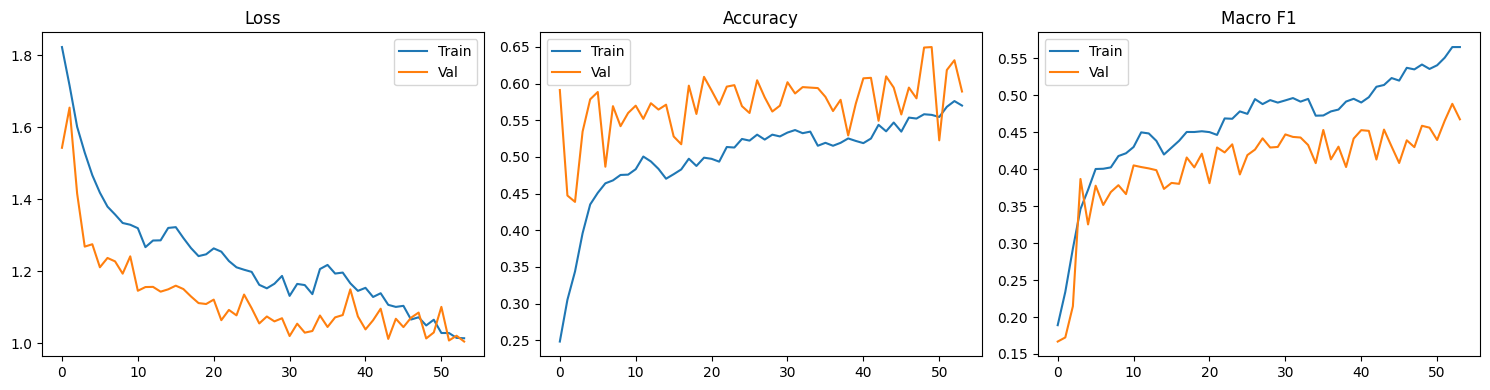


FINAL EVALUATION


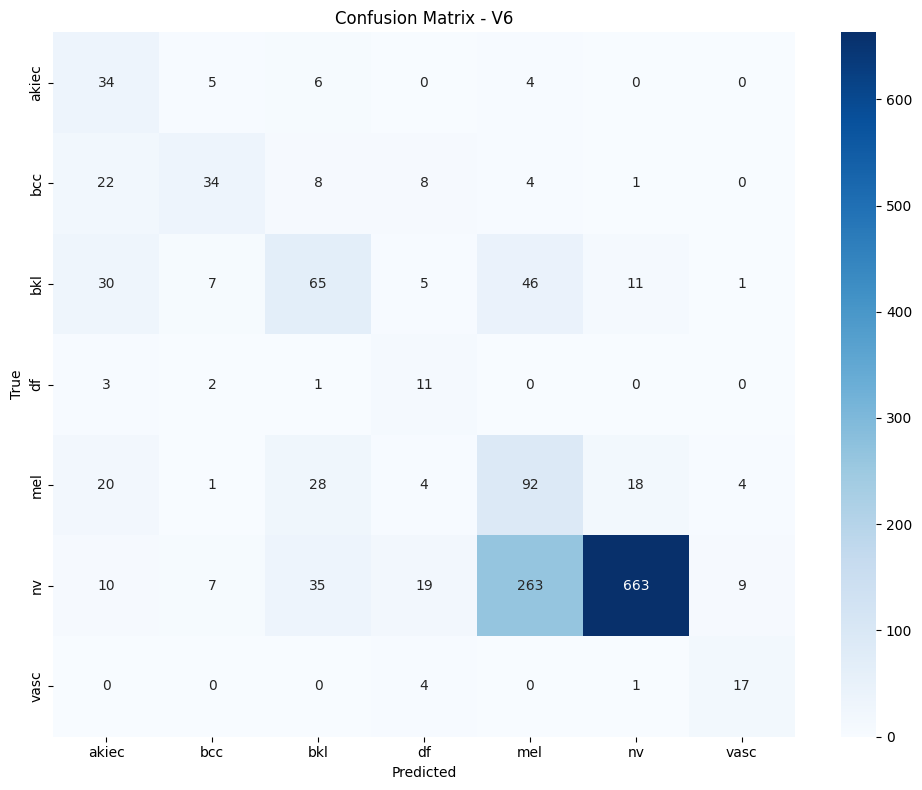


V6 TEST RESULTS - Morphology + Cross-Attention
Accuracy: 0.6094
Macro F1: 0.4861
Weighted F1: 0.6563
Macro AUC: 0.9033

Per-class metrics:
  akiec : Precision=0.2857, Recall=0.6939, F1=0.4048
  bcc   : Precision=0.6071, Recall=0.4416, F1=0.5113
  bkl   : Precision=0.4545, Recall=0.3939, F1=0.4221
  df    : Precision=0.2157, Recall=0.6471, F1=0.3235
  mel   : Precision=0.2249, Recall=0.5509, F1=0.3194
  nv    : Precision=0.9553, Recall=0.6590, F1=0.7800
  vasc  : Precision=0.5484, Recall=0.7727, F1=0.6415

Target (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733
NEEDS IMPROVEMENT

Results saved to: D:\Kimi phase 3\output\checkpoints_phase3


In [58]:
# Plot training curves and evaluate the best checkpoint on the test set.
trainer.plot_history()
results = run_final_evaluation(model, test_loader, config, config.SAVE_DIR)